## Завдання І, ІІ рівнів складності – максимально 7, 8 балів відповідно.
### Розробити програмний скрипт мовою Python що забезпечує аналіз властивостей і характеристик вихідних даних відповідно до етапів:
1. Модель генерації випадкової величини за заданим у табл.1 додатку 1 закону
розподілу;
2. Модель зміни (ідеальний тренд) досліджуваного процесу за заданим у табл.1
додатку 1 законом;
3. Адитивна модель статистичної вибірки відповідно до синтезованих в п.1,2 моделей
випадкової (стохастична) і невипадкової складових. Параметри закону розподілу та закону
зміни досліджуваного процесу обрати самостійно.
4. Визначення статистичних (числових) характеристик сформованих в п.1,3 вибірок
(дисперсія, середньоквадратичне відхилення, математичне очікування, гістограма закону
розподілу).
5. Визначення статистичних характеристик реальних даних, заданих файлом
Oschadbank (USD).xls за умов табл. 1 додатку 1.
6. Провести аналіз отриманих результатів та верифікацію розробленого скрипта.

# Завдання ІІІ рівня – максимально 10 балів.
1. Провести парсинг самостійно обраного сайту. Вміст даних, що підлягають парсингу
– обрати самостійно.
2. Результати парсингу зберегти у файлі. Тип файлу обрати самостійно.
3. Оцінити динаміку тренду реальних даних.
4. Здійснити визначення статистичних характеристик результатів парсингу.
5. Синтезувати та верифікувати модель даних, аналогічних за трендом і
статистичними характеристиками реальним даним, які є результатом парсингу.
6. Провести аналіз отриманих результатів.

P.s: *Завдання III рівня було обрано до виконання*

### 1. Провести парсинг самостійно обраного сайту. Вміст даних, що підлягають парсингу

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import json
from sklearn.preprocessing import StandardScaler
import statsmodels.tsa.seasonal as seas
import statsmodels.api as sm
from bs4 import BeautifulSoup
from pathlib import Path

In [2]:
# Parsing the website and getting the data
url = 'https://charts.finance.ua/ua/currency/data-archive?for=interbank&source=1&indicator=eur'
response = requests.get(url)
js = json.JSONDecoder().decode(response.text)

# Turning list to DataFrame for more comfortable usage later and cutting to 2024
df = pd.DataFrame(js, columns=['Date', 'Buy', 'Sell'])
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', dayfirst=True)
df = df[(df['Date'] < '2024-12-31') & (df['Date'] > '2023-12-31')].reset_index(drop=True)
df[['Buy', 'Sell']] = df[['Buy', 'Sell']].astype(float)

js

[['03/25/1999', '4.2767', '4.3233'],
 ['03/26/1999', '4.2800', '4.3000'],
 ['03/29/1999', '4.2200', '4.3100'],
 ['03/30/1999', '4.2000', '4.2300'],
 ['03/31/1999', '4.2085', '4.2350'],
 ['04/01/1999', '4.1939', '4.2000'],
 ['04/05/1999', '4.2276', '4.2567'],
 ['04/06/1999', '4.2251', '4.2450'],
 ['04/07/1999', '4.2290', '4.2567'],
 ['04/08/1999', '4.2000', '4.2400'],
 ['04/09/1999', '4.2267', '4.2667'],
 ['04/13/1999', '4.2450', '4.2700'],
 ['04/14/1999', '4.2400', '4.2500'],
 ['04/15/1999', '4.2300', '4.2553'],
 ['04/16/1999', '4.1900', '4.2200'],
 ['04/19/1999', '4.1833', '4.2033'],
 ['04/20/1999', '4.1650', '4.1900'],
 ['04/21/1999', '4.1600', '4.1867'],
 ['04/22/1999', '4.1600', '4.1900'],
 ['04/23/1999', '4.1550', '4.1750'],
 ['04/26/1999', '4.1611', '4.1767'],
 ['04/27/1999', '4.1600', '4.1900'],
 ['04/28/1999', '4.1715', '4.1865'],
 ['04/29/1999', '4.1700', '4.1900'],
 ['04/30/1999', '4.1571', '4.1800'],
 ['05/05/1999', '4.1563', '4.1750'],
 ['05/06/1999', '4.1775', '4.2000'],
 

In [3]:
df

,Date,Buy,Sell
0,2024-01-01,42.2320,42.2499
1,2024-01-02,41.7985,41.8107
2,2024-01-03,41.6434,41.6559
3,2024-01-04,41.7846,41.8060
4,2024-01-05,41.7666,41.8175
...,...,...,...
256,2024-12-24,43.6261,43.6301
257,2024-12-25,43.5848,43.6140
258,2024-12-26,43.5449,43.5552
259,2024-12-27,43.7516,43.7703


### 2. Результати парсингу зберегти у файлі. Тип файлу обрати самостійно.

In [4]:
# Saving the results of parsing to a file(.csv format)
file_path = Path('data/Eur_Uah.csv')
file_path.parent.mkdir(parents=True, exist_ok=True)

if file_path.is_file():
    print(f'Файл "{file_path}" вже існує.')
else:
    df.to_csv(file_path, index=False)
    print(f'Файл успішно збережено до "{file_path}"')

Файл "data/Eur_Uah.csv" вже існує.


### 3. Оцінити динаміку тренду реальних даних.


In [5]:
def draw_plots(dtf, date_arg, second_arg):
    fig, ax = plt.subplots(2, 1)
    fig.set_figheight(10)
    # fig.tight_layout()

    # Common plot with basic information and EMA trend
    ax[0].set_xlabel('Графік реальних даних з накладеною EMA')
    ax[0].plot(dtf[date_arg], dtf[second_arg], color='g')
    ax[0].plot(dtf[date_arg], dtf[second_arg].ewm(span=50, adjust=False).mean(), color='b')

    # Histogram
    ax[1].hist(dtf[second_arg], bins=np.arange(round(dtf[second_arg].min()), round(dtf[second_arg].max() + 1), 0.5), edgecolor='black')
    ax[1].set_xlabel('Графік емпіричного розподілу частот')
    # dtf.hist(by=second_arg, ax=ax[1], color='g')

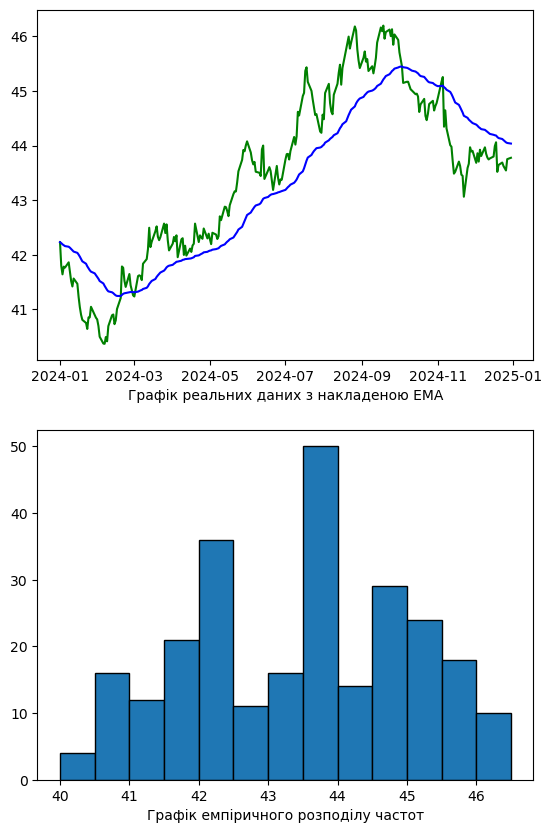

In [6]:
draw_plots(df, 'Date', 'Buy')

In [7]:
# Decomposition
df_decomposed = df.set_index('Date')
decomposition = seas.seasonal_decompose(x=df_decomposed['Buy'], period=5, model='additive')
df_decomposed = pd.concat([df_decomposed, decomposition.trend, decomposition.seasonal, decomposition.resid], axis=1)

df_decomposed

,Buy,Sell,trend,seasonal,resid
Date,,,,,
2024-01-01,42.2320,42.2499,NaN,0.056736,NaN
2024-01-02,41.7985,41.8107,NaN,0.030723,NaN
2024-01-03,41.6434,41.6559,41.84502,-0.001000,-0.200620
2024-01-04,41.7846,41.8060,41.77128,-0.050321,0.063641
2024-01-05,41.7666,41.8175,41.74880,-0.036137,0.053937
...,...,...,...,...,...
2024-12-24,43.6261,43.6301,43.61830,0.030723,-0.022923
2024-12-25,43.5848,43.6140,43.63950,-0.001000,-0.053700
2024-12-26,43.5449,43.5552,43.65688,-0.050321,-0.061659


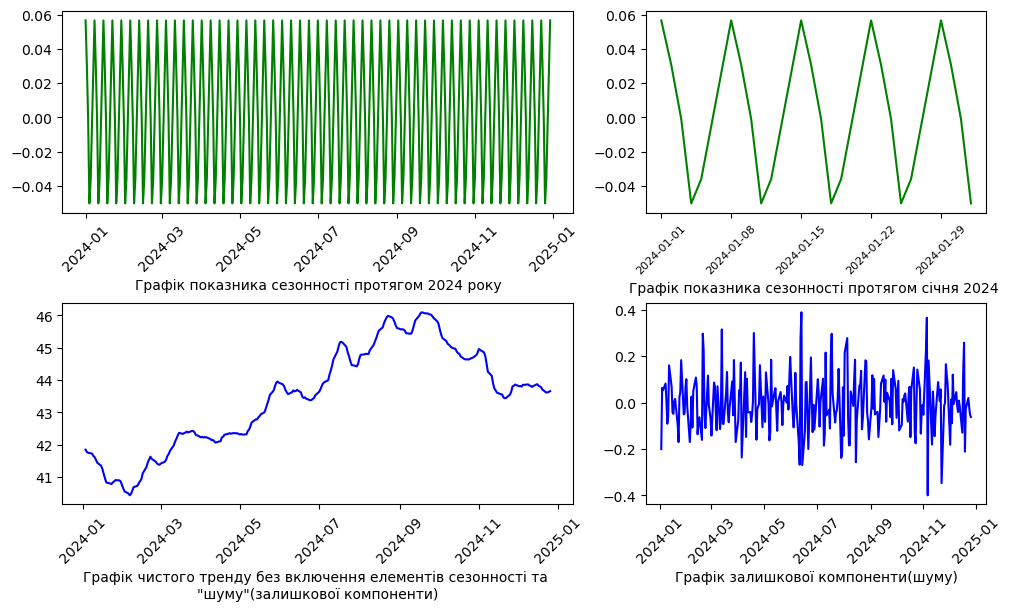

In [8]:
# Setting some additional parameters for the next plots
fig, ax = plt.subplots(2, 2, layout='constrained', width_ratios=[0.6, 0.4])
fig.set_figheight(6)
fig.set_figwidth(10)
ax[0][0].tick_params(axis='x', labelrotation=45)
ax[0][0].set_xlabel('Графік показника сезонності протягом 2024 року')
ax[0][1].set_xticks(ticks=df[::5]['Date'], labels=df[::5]['Date'].astype(str), rotation=45, size=8)
ax[0][1].set_xlabel('Графік показника сезонності протягом січня 2024 ')
ax[1][0].tick_params(axis='x', labelrotation=45)
ax[1][0].set_xlabel('Графік чистого тренду без включення елементів сезонності та \n"шуму"(залишкової компоненти)')
ax[1][1].tick_params(axis='x', labelrotation=45)
ax[1][1].set_xlabel('Графік залишкової компоненти(шуму)')
# fig.tight_layout()

ax[0][0].plot(df_decomposed['seasonal'], color='g')
ax[0][1].plot(df_decomposed['seasonal']['2024/01/01':'2024/02/01'], color='g', )
ax[1][0].plot(df_decomposed['trend'], color='b')
ax[1][1].plot(df_decomposed['resid'], color='b')
# ax[0].plot(dtf[date_arg], dtf[second_arg].ewm(span=50, adjust=False).mean(), color='b')

In [9]:
df_decomposed

,Buy,Sell,trend,seasonal,resid
Date,,,,,
2024-01-01,42.2320,42.2499,NaN,0.056736,NaN
2024-01-02,41.7985,41.8107,NaN,0.030723,NaN
2024-01-03,41.6434,41.6559,41.84502,-0.001000,-0.200620
2024-01-04,41.7846,41.8060,41.77128,-0.050321,0.063641
2024-01-05,41.7666,41.8175,41.74880,-0.036137,0.053937
...,...,...,...,...,...
2024-12-24,43.6261,43.6301,43.61830,0.030723,-0.022923
2024-12-25,43.5848,43.6140,43.63950,-0.001000,-0.053700
2024-12-26,43.5449,43.5552,43.65688,-0.050321,-0.061659


### 4. Здійснити визначення статистичних характеристик результатів парсингу.

In [10]:
# Normality of data
norm_df = df.copy().drop('Sell', axis=1)
norm_df[['Buy']] = StandardScaler().fit_transform(df[['Buy']])

y = norm_df['Buy']

x = np.arange(len(norm_df))
X_poly = pd.DataFrame({'x': x, 'x_squared': x**2})

X_poly_const = sm.add_constant(X_poly)

model = sm.OLS(y, X_poly_const)
results = model.fit()
print(results.summary())

print(f'\nСереднє квадратичне відхилення реальних даних(стовпчика "Buy"): {df['Buy'].std()}')
print(f'Дисперсія реальних даних(стовпчика "Buy"): {df['Buy'].var()}')
print(f'Математичне сподівання(середнє значення стовпчика "Buy" реальних даних): {df['Buy'].mean()}')

print(f'\nСереднє квадратичне відхилення нормалізованих даних(стовпчика "Buy"): {norm_df['Buy'].std()}')
print(f'Дисперсія нормалізованих даних(стовпчика "Buy"): {norm_df['Buy'].var()}')
print(f'Математичне сподівання(середнє значення стовпчика "Buy" нормалізованих даних): {norm_df['Buy'].mean()}')

                            OLS Regression Results                            
Dep. Variable:                    Buy   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     470.8
Date:                Wed, 17 Sep 2025   Prob (F-statistic):           8.05e-87
Time:                        03:42:23   Log-Likelihood:                -169.80
No. Observations:                 261   AIC:                             345.6
Df Residuals:                     258   BIC:                             356.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2768      0.086    -26.488      0.0

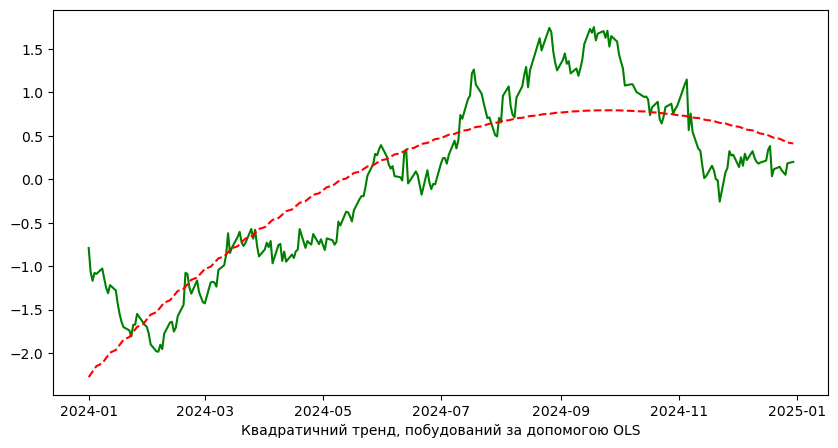

In [11]:
norm_df['OLS_trend'] = results.predict(X_poly_const)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(norm_df['Date'], norm_df['Buy'], label='Реальні дані', color='g')
ax.plot(norm_df['Date'], norm_df['OLS_trend'], label='Тренд OLS', color='r', linestyle='--')
ax.set_xlabel('Квадратичний тренд, побудований за допомогою OLS')
ax.plot();


### 5. Синтезувати та верифікувати модель даних, аналогічних за трендом і статистичними характеристиками реальним даним, які є результатом парсингу.
*Ця частина буде складатися з 2 етапів, бо алгоритмів, які ми будемо тут розглядати теж 2*
1. Отриманий за допомогою МНК та моделі OLS

Аномальні дані:
        Date       Buy  OLS_trend  OLS_resid  upper_3sigma  lower_3sigma
0 2024-01-01 -0.791294  -2.276845   1.485551     -0.882869     -3.670821


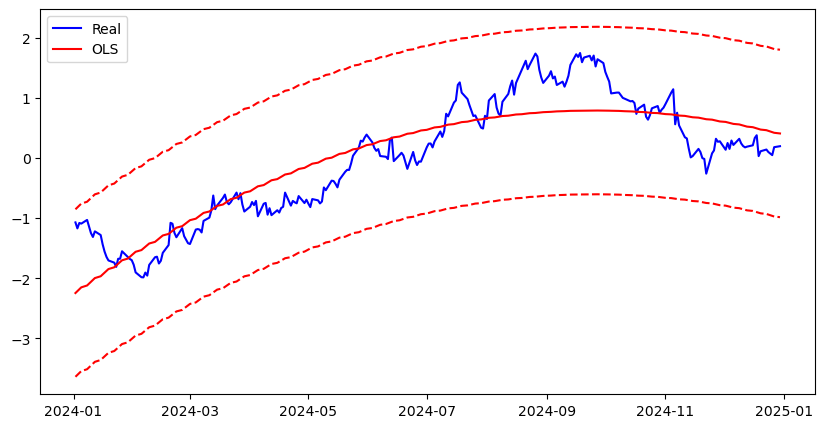

In [12]:
# First model
norm_df['OLS_resid'] = norm_df['Buy'] - norm_df['OLS_trend']
OLS_resid_std = norm_df['OLS_resid'].std()
norm_df['upper_3sigma'] = norm_df['OLS_trend'] + 3 * OLS_resid_std
norm_df['lower_3sigma'] = norm_df['OLS_trend'] - 3 * OLS_resid_std
print('Аномальні дані:')
print(norm_df[norm_df['OLS_resid'] > 3 * OLS_resid_std])

# Deleting anomalies
# norm_df['Buy'] = norm_df['Buy'].mask(norm_df['OLS_resid'] > 3 * OLS_resid_std, norm_df['OLS_trend'], axis=0)  # this line is for changing to the trend value
norm_df.drop(index=list(norm_df[norm_df['OLS_resid'] > 3 * OLS_resid_std].index), inplace=True)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(norm_df['Date'], norm_df['Buy'], "b-", label="Real")
ax.plot(norm_df['Date'], norm_df['OLS_trend'], "r", label="OLS")
ax.plot(norm_df['Date'], norm_df['upper_3sigma'], "r--")
ax.plot(norm_df['Date'], norm_df['lower_3sigma'], "r--")
ax.legend(loc="best")
plt.show()

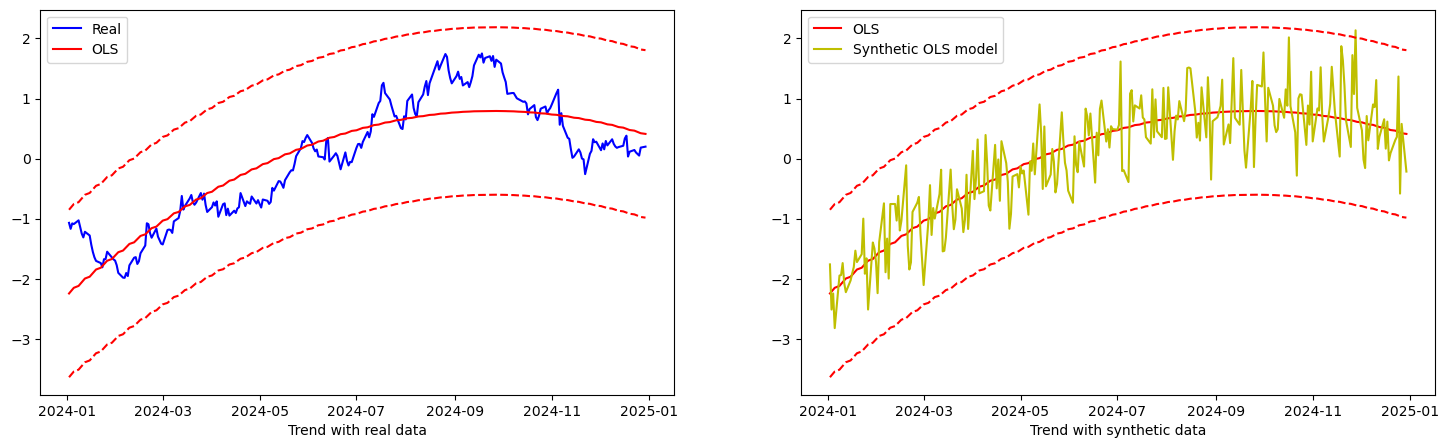

In [13]:
# Synthesising synthetic data and applying it to the trend values
synthetic_noise = np.random.normal(loc=0, scale=OLS_resid_std, size=len(norm_df))
norm_df['Synthetic_Buy'] = norm_df['OLS_trend'] + synthetic_noise

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].plot(norm_df['Date'], norm_df['Buy'], "b-", label="Real")
ax[0].plot(norm_df['Date'], norm_df['OLS_trend'], "r", label="OLS")
ax[0].plot(norm_df['Date'], norm_df['upper_3sigma'], "r--")
ax[0].plot(norm_df['Date'], norm_df['lower_3sigma'], "r--")
ax[0].set_xlabel('Trend with real data')
ax[0].legend(loc="best")

ax[1].plot(norm_df['Date'], norm_df['OLS_trend'], "r", label="OLS")
ax[1].plot(norm_df['Date'], norm_df['Synthetic_Buy'], "y", label="Synthetic OLS model")
ax[1].plot(norm_df['Date'], norm_df['upper_3sigma'], "r--")
ax[1].plot(norm_df['Date'], norm_df['lower_3sigma'], "r--")
ax[1].set_xlabel('Trend with synthetic data')
ax[1].legend(loc="best")
plt.show()

In [14]:
norm_df

,Date,Buy,OLS_trend,OLS_resid,upper_3sigma,lower_3sigma,Synthetic_Buy
1,2024-01-02,-1.069269,-2.244982,1.175713,-0.851006,-3.638958,-1.760865
2,2024-01-03,-1.168724,-2.213285,1.044561,-0.819309,-3.607261,-2.512557
3,2024-01-04,-1.078182,-2.181755,1.103573,-0.787779,-3.575731,-2.244705
4,2024-01-05,-1.089724,-2.150390,1.060666,-0.756414,-3.544366,-2.821530
5,2024-01-08,-1.027717,-2.119192,1.091475,-0.725216,-3.513168,-1.946494
...,...,...,...,...,...,...,...
256,2024-12-24,0.102651,0.455231,-0.352581,1.849208,-0.938745,0.361499
257,2024-12-25,0.076168,0.444546,-0.368379,1.838523,-0.949430,1.367111
258,2024-12-26,0.050583,0.433695,-0.383113,1.827672,-0.960281,-0.581974
259,2024-12-27,0.183126,0.422678,-0.239552,1.816654,-0.971298,0.578076


2. Отриманий під час декомпозиції

Аномальні дані:
Empty DataFrame
Columns: [Date, Buy, Sell, trend, seasonal, resid, upper_3sigma, lower_3sigma]
Index: []


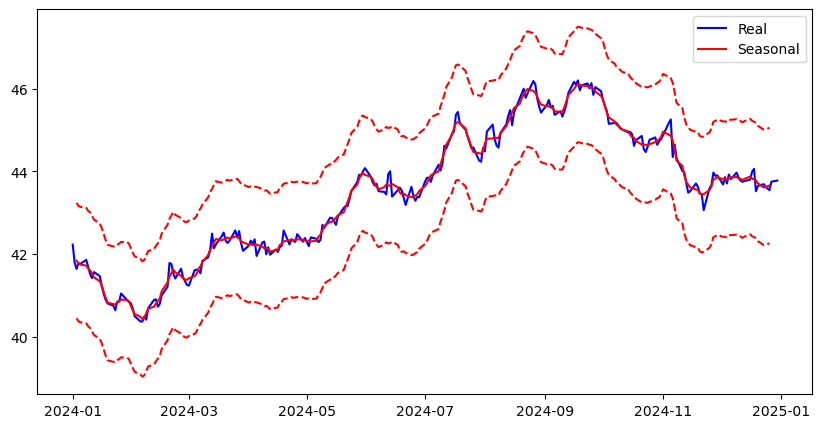

In [15]:
# Second model
df_decomposed.reset_index(inplace=True)
seas_resid_std = df_decomposed['resid'].std()
df_decomposed['upper_3sigma'] = df_decomposed['trend'] + 3 * OLS_resid_std
df_decomposed['lower_3sigma'] = df_decomposed['trend'] - 3 * OLS_resid_std
print('Аномальні дані:')
print(df_decomposed[df_decomposed['resid'] > 3 * OLS_resid_std])

# Deleting anomalies
# df_decomposed['Buy'] = df_decomposed['Buy'].mask(df_decomposed['resid'] > 3 * OLS_resid_std, df_decomposed['trend'], axis=0)  # this line is for changing to the trend value
df_decomposed.drop(index=list(df_decomposed[df_decomposed['resid'] > 3 * OLS_resid_std].index), inplace=True)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_decomposed['Date'], df_decomposed['Buy'], "b-", label="Real")
ax.plot(df_decomposed['Date'], df_decomposed['trend'], "r", label="Seasonal")
ax.plot(df_decomposed['Date'], df_decomposed['upper_3sigma'], "r--")
ax.plot(df_decomposed['Date'], df_decomposed['lower_3sigma'], "r--")
ax.legend(loc="best")
plt.show()

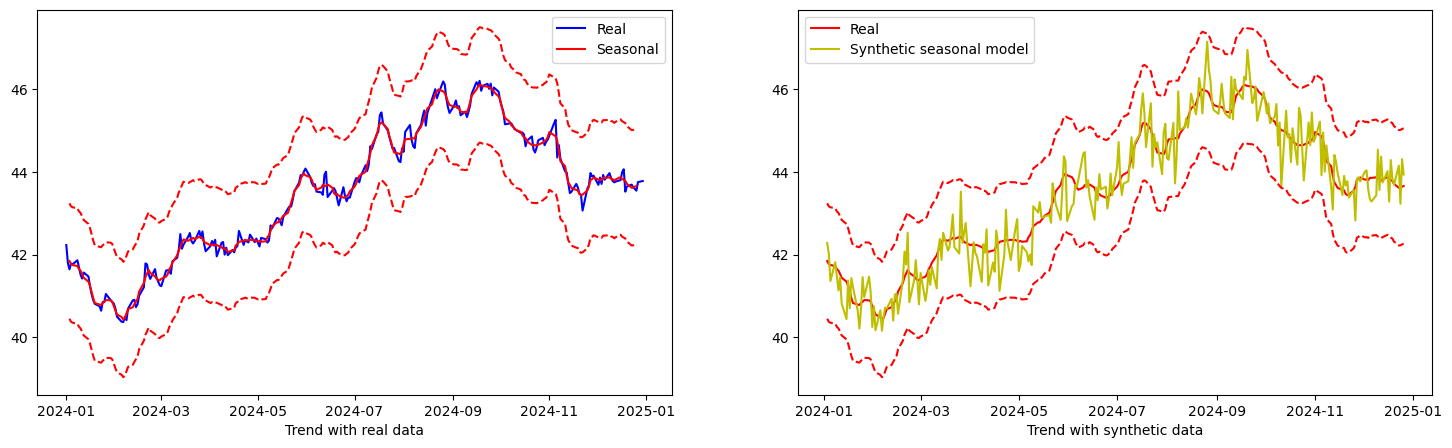

In [16]:
# Synthesising synthetic data and applying it to the trend values
synthetic_noise = np.random.normal(loc=0, scale=OLS_resid_std, size=len(df_decomposed))
df_decomposed['Synthetic_Buy'] = df_decomposed['trend'] + synthetic_noise

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].plot(df_decomposed['Date'], df_decomposed['Buy'], "b-", label="Real")
ax[0].plot(df_decomposed['Date'], df_decomposed['trend'], "r", label="Seasonal")
ax[0].plot(df_decomposed['Date'], df_decomposed['upper_3sigma'], "r--")
ax[0].plot(df_decomposed['Date'], df_decomposed['lower_3sigma'], "r--")
ax[0].set_xlabel('Trend with real data')
ax[0].legend(loc="best")

ax[1].plot(df_decomposed['Date'], df_decomposed['trend'], "r", label="Real")
ax[1].plot(df_decomposed['Date'], df_decomposed['Synthetic_Buy'], "y", label="Synthetic seasonal model")
ax[1].plot(df_decomposed['Date'], df_decomposed['upper_3sigma'], "r--")
ax[1].plot(df_decomposed['Date'], df_decomposed['lower_3sigma'], "r--")
ax[1].set_xlabel('Trend with synthetic data')
ax[1].legend(loc="best")
plt.show()

### Верифікація моделей

In [17]:
def models_resid_verification(dtf, resid_real, resid_synthetic):
    print(dtf[['Synthetic_Buy', 'Buy']].describe())

    fig, ax = plt.subplots(1, 2, figsize=(18, 5))

    ax[0].hist(resid_real, label="Real")
    ax[0].set_xlabel('Resid of the real data')
    ax[0].legend(loc="best")

    ax[1].hist(resid_synthetic, label="Real")
    ax[1].set_xlabel('Resid of the synthetic data')
    ax[1].legend(loc="best")
    plt.show()

OLS model
       Synthetic_Buy         Buy
count     260.000000  260.000000
mean        0.020025    0.003043
std         1.011280    1.002644
min        -2.821530   -1.984246
25%        -0.596952   -0.782477
50%         0.255246    0.118746
75%         0.776271    0.833001
max         2.135928    1.750687


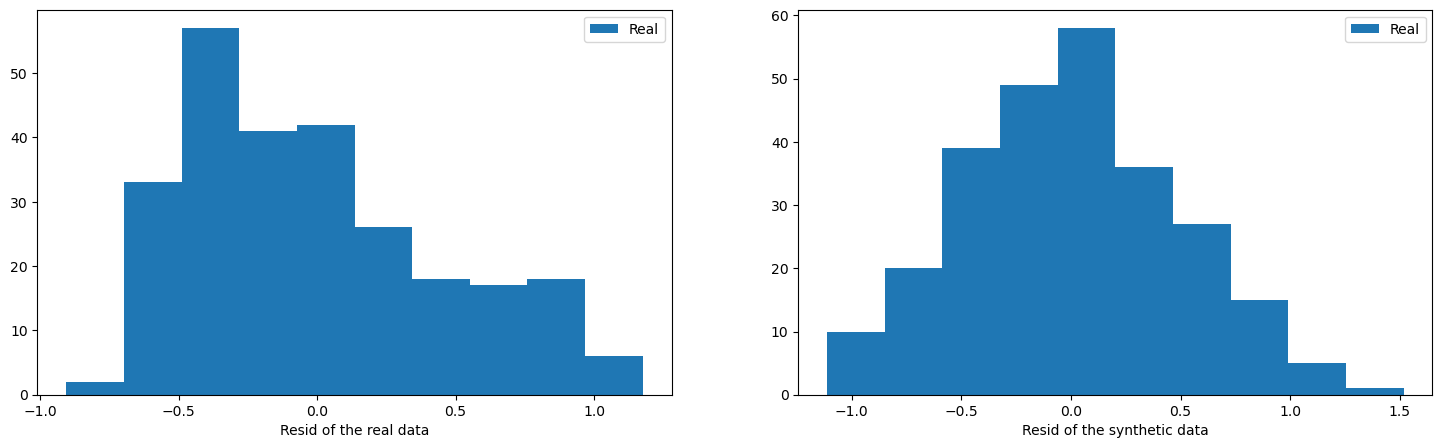

In [21]:
print('OLS model')
models_resid_verification(norm_df, norm_df['OLS_resid'], norm_df['Synthetic_Buy'] - norm_df['OLS_trend'])

Seasonal decomposition model
       Synthetic_Buy         Buy
count     257.000000  261.000000
mean       43.459745   43.466017
std         1.666628    1.562489
min        40.161297   40.371600
25%        42.045104   42.238400
50%        43.623617   43.645600
75%        44.828420   44.760900
max        47.140654   46.196200


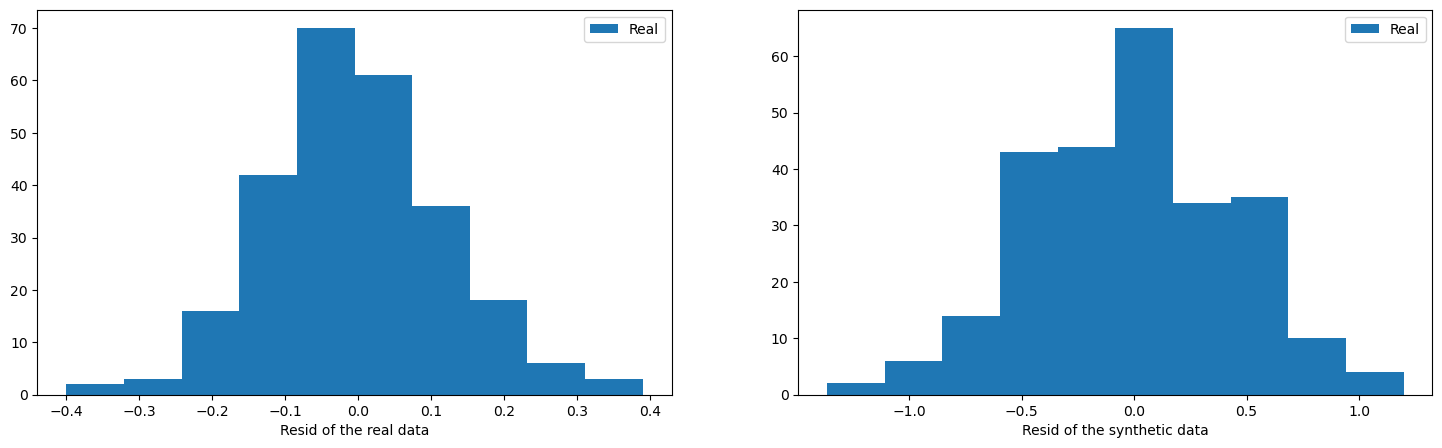

In [20]:
print('Seasonal decomposition model')
models_resid_verification(df_decomposed, df_decomposed['resid'], df_decomposed['Synthetic_Buy'] - df_decomposed['trend'])